Top risky entities:
        fromtoid  recent_avg_volume  previous_avg_volume  decline_pct  \
681  ABBT0057280         187.700000         34766.400000   -99.460111   
633  ABBT0056167           0.100000             7.266667   -98.623853   
639  ABBT0056294           0.566667            21.000000   -97.301587   
595  ABBT0055569           1.566667            44.366667   -96.468820   
217  ABBT0045490           0.100000             2.633333   -96.202532   
117  ABBT0042607        1122.466667         22672.400000   -95.049193   
391  ABBT0050533           0.500000             9.966667   -94.983278   
465  ABBT0052207          30.333333           489.100000   -93.798133   
321  ABBT0048886           1.900000            22.433333   -91.530461   
464  ABBT0052192           2.366667            19.066667   -87.587413   
666  ABBT0057000           2.733333            21.066667   -87.025316   
53   ABBT0041056           8.700000            66.900000   -86.995516   
342  ABBT0049334           0.26

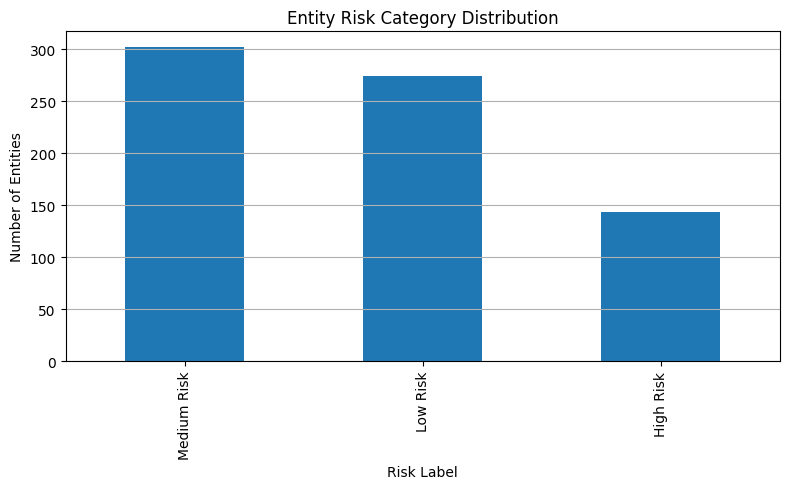


entity_risk_scores.csv has been saved.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load file
df = pd.read_csv("entity_month_volume_risk_prep.csv")

# 2. Clean columns
df["productionmonth"] = pd.to_datetime(df["productionmonth"])
df = df.rename(columns={"Total Volume": "volume"})
df = df.sort_values(["fromtoid", "productionmonth"])

# 3. Keep only entities with enough history
entity_counts = df.groupby("fromtoid")["productionmonth"].count().reset_index(name="month_count")
valid_entities = entity_counts[entity_counts["month_count"] >= 6]["fromtoid"]
df = df[df["fromtoid"].isin(valid_entities)].copy()

# 4. Function to calculate risk metrics per entity
risk_rows = []

for entity, group in df.groupby("fromtoid"):
    group = group.sort_values("productionmonth").copy()

    # use last 3 months vs previous 3 months
    recent_3 = group.tail(3)
    previous_3 = group.iloc[-6:-3]

    if len(recent_3) < 3 or len(previous_3) < 3:
        continue

    recent_avg = recent_3["volume"].mean()
    previous_avg = previous_3["volume"].mean()

    # decline %
    if previous_avg == 0:
        decline_pct = 0
    else:
        decline_pct = ((recent_avg - previous_avg) / previous_avg) * 100

    # volatility in recent 6 months
    recent_6 = group.tail(6)
    volatility = recent_6["volume"].std()

    # simple risk scoring logic
    risk_score = 0

    # low recent production
    if recent_avg < df["volume"].quantile(0.25):
        risk_score += 1

    # declining production
    if decline_pct < -10:
        risk_score += 1

    # high volatility
    if volatility > df["volume"].quantile(0.75):
        risk_score += 1

    # assign label
    if risk_score >= 2:
        risk_label = "High Risk"
    elif risk_score == 1:
        risk_label = "Medium Risk"
    else:
        risk_label = "Low Risk"

    risk_rows.append({
        "fromtoid": entity,
        "recent_avg_volume": recent_avg,
        "previous_avg_volume": previous_avg,
        "decline_pct": decline_pct,
        "recent_volatility": volatility,
        "risk_score": risk_score,
        "risk_label": risk_label
    })

# 5. Build risk table
risk_df = pd.DataFrame(risk_rows)

# 6. Sort risky entities first
risk_df = risk_df.sort_values(
    by=["risk_score", "decline_pct"],
    ascending=[False, True]
)

# 7. Show top risky entities
print("Top risky entities:")
print(risk_df.head(20))

# 8. Count risk labels
risk_counts = risk_df["risk_label"].value_counts()
print("\nRisk label counts:")
print(risk_counts)

# 9. Plot risk distribution
plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")
plt.title("Entity Risk Category Distribution")
plt.xlabel("Risk Label")
plt.ylabel("Number of Entities")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# 10. Save results
risk_df.to_csv("entity_risk_scores.csv", index=False)
print("\nentity_risk_scores.csv has been saved.")